In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("ihelon/coffee-sales")

print(f"Dataset terunduh di: {path}")

files = os.listdir(path)
print(f"Daftar file: {files}")


if "index.csv" in files:
    df = pd.read_csv(os.path.join(path, "index.csv"))
    print("\n--- Berhasil Load Data ---")
    print(df.head())
else:
    print("\nFile index.csv tidak ditemukan, coba cek daftar file di atas.")

Dataset terunduh di: C:\Users\user\.cache\kagglehub\datasets\ihelon\coffee-sales\versions\21
Daftar file: ['index_1.csv', 'index_2.csv']

File index.csv tidak ditemukan, coba cek daftar file di atas.


In [ ]:
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("ihelon/coffee-sales")

path_1 = os.path.join(path, "index_1.csv")
path_2 = os.path.join(path, "index_2.csv")

df1 = pd.read_csv(path_1)
df2 = pd.read_csv(path_2)

#MENGGABUNGKAN DATA
df = pd.concat([df1, df2], ignore_index=True)

print(f"Data 1: {len(df1)} baris")
print(f"Data 2: {len(df2)} baris")
print(f"Total setelah digabung: {len(df)} baris")

# Tampilkan 5 baris pertama
print(df.head())

Data 1: 3636 baris
Data 2: 262 baris
Total setelah digabung: 3898 baris
         date                 datetime cash_type                 card  money  \
0  2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#Cek missing value 
print("Cek null:")
print(df.isnull().sum())

print("\nAda null atau tidak:")
print(df.isnull().any())

print("\nTotal semua null:")
print(df.isnull().sum().sum())


Cek null:
date             0
datetime         0
cash_type        0
card           351
money            0
coffee_name      0
tahun            0
dtype: int64

Ada null atau tidak:
date           False
datetime       False
cash_type      False
card            True
money          False
coffee_name    False
tahun          False
dtype: bool

Total semua null:
351


In [ ]:
df_clean = df.dropna(subset=['coffee_name', 'cash_type'])

# Kolom numerik → isi dengan rata-rata 
mean_money = df_clean['money'].mean()
df_clean['money'] = df_clean['money'].fillna(mean_money)

# Kolom tambahan 
df_clean['card'] = df_clean['card'].fillna('N/A')

print("\nSetelah penanganan null:")
print(df_clean.isnull().sum())



Setelah penanganan null:
date           0
datetime       0
cash_type      0
card           0
money          0
coffee_name    0
tahun          0
dtype: int64


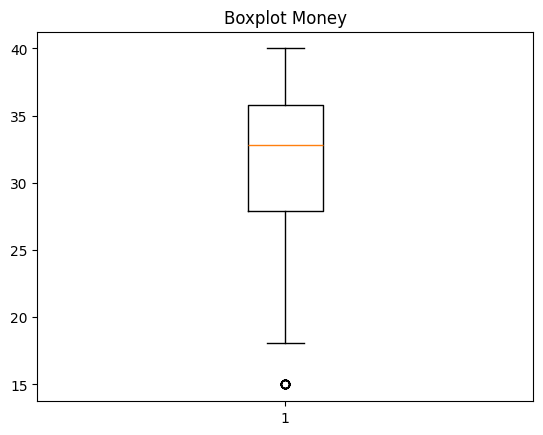

In [55]:
plt.boxplot(df_clean['money'])
plt.title("Boxplot Money")
plt.show()

# Hitung IQR
Q1 = df_clean['money'].quantile(0.25)
Q3 = df_clean['money'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

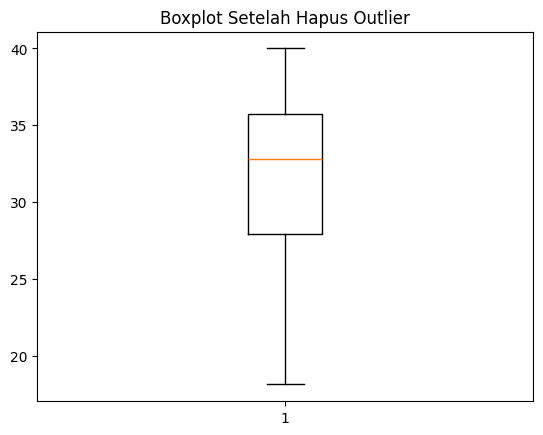

In [ ]:
outlier_index = df_clean[
    (df_clean['money'] < lower) | 
    (df_clean['money'] > upper)
].index

# Hapus data outlier
df_final = df_clean.drop(outlier_index)

# boxplot setelah dibersihkan
plt.boxplot(df_final['money'])
plt.title("Boxplot Setelah Hapus Outlier")
plt.show()

In [57]:
print("\nJumlah data awal:", len(df))
print("Setelah cleaning:", len(df_final))


Jumlah data awal: 3898
Setelah cleaning: 3882


In [ ]:
#Deskriptif (money)
import numpy as np
import pandas as pd

num_cols = ['money']

hasil = {}

for col in num_cols:
    nilai = df[col].dropna().values # ubah ke numpy array

    hasil[col] = {
        'min': nilai.min(),
        'max': nilai.max(),
        'mean': nilai.mean(),
        'median': np.median(nilai),
        'std': nilai.std(ddof=1), # ddof=1 biar sama kayak pandas
        'var': nilai.var(ddof=1)
    }

# ubah ke dataframe
statistik = pd.DataFrame(hasil).T

print("Statistik Deskriptif:")
print(statistik)

Statistik Deskriptif:
        min   max     mean  median      std        var
money  15.0  40.0  31.3806   32.82  5.06461  25.650273


In [59]:
import numpy as np

# ambil kolom money dan hilangkan yang kosong
uang = df['money'].dropna()

stats_uang = {
    'jumlah_data': len(uang),
    'min': uang.min(),
    'max': uang.max(),
    'mean': uang.mean(),
    'rentang': uang.max() - uang.min(),
    'median': np.median(uang),
    'std': uang.std(ddof=1),
    'var': uang.var(ddof=1)
}

print("\nStatistik Deskriptif untuk kolom 'money':")
for k, v in stats_uang.items():
    print(f"{k}: {v}")


Statistik Deskriptif untuk kolom 'money':
jumlah_data: 3898
min: 15.0
max: 40.0
mean: 31.380600307850177
rentang: 25.0
median: 32.82
std: 5.064609884870963
var: 25.65027328593267


In [61]:
df.describe()

,datetime,money,tahun
count,3898,3898.00000,3898.000000
mean,2024-10-11 06:25:20.199450,31.38060,2024.309133
min,2024-03-01 10:15:50.520000,15.00000,2024.000000
25%,2024-07-16 23:53:19.049750,27.92000,2024.000000
50%,2024-10-15 21:26:44.176000,32.82000,2024.000000
75%,2025-02-03 14:36:55.778250,35.76000,2025.000000
max,2025-03-23 21:23:11,40.00000,2025.000000
std,NaN,5.06461,0.462195


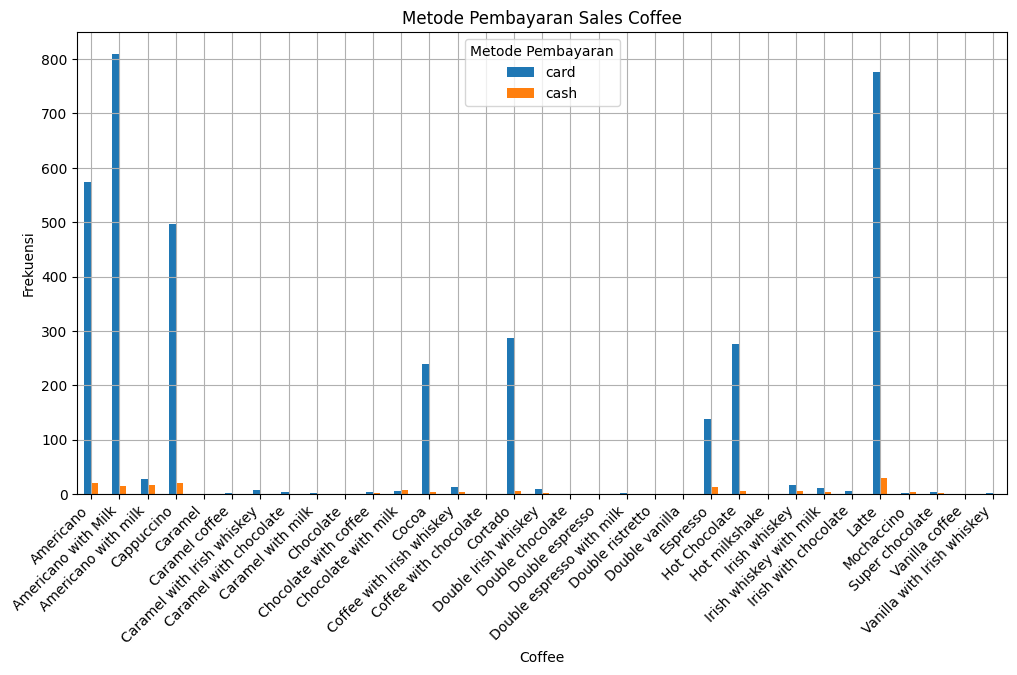

In [ ]:
coffee_payment_counts = df_final.groupby(['coffee_name', 'cash_type']).size().unstack()


coffee_payment_counts.plot(kind='bar', stacked=False, figsize=(12,6))
plt.title('Metode Pembayaran Sales Coffee')
plt.xlabel('Coffee')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metode Pembayaran')
plt.grid(True)
plt.show()


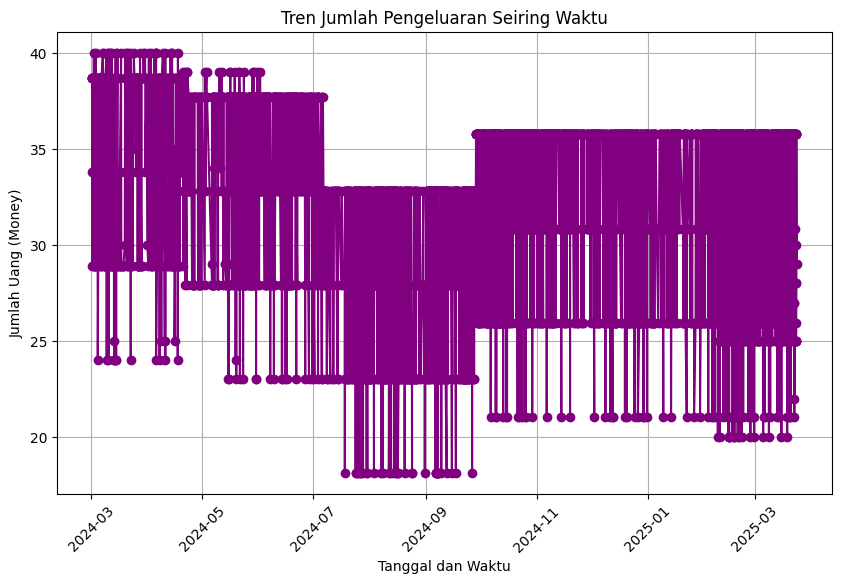

In [ ]:
df_final['datetime'] = pd.to_datetime(df_final['datetime'], errors='coerce')

df_final = df_final.sort_values('datetime')

plt.figure(figsize=(10,6))
plt.plot(df_final['datetime'], df_final['money'], color='purple', linestyle='-', marker='o')

plt.title('Tren Jumlah Pengeluaran Seiring Waktu')  
plt.xlabel('Tanggal dan Waktu')                    
plt.ylabel('Jumlah Uang (Money)')                  
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

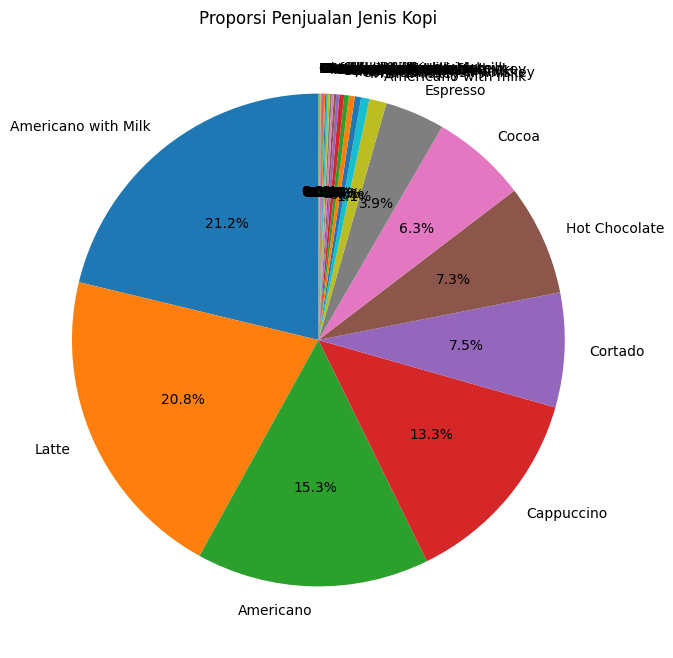

In [ ]:
coffee_counts = df_final['coffee_name'].value_counts()

plt.figure(figsize=(8, 8)) 
coffee_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90, 
    title='Proporsi Penjualan Jenis Kopi'
)

plt.ylabel('') 
plt.show()

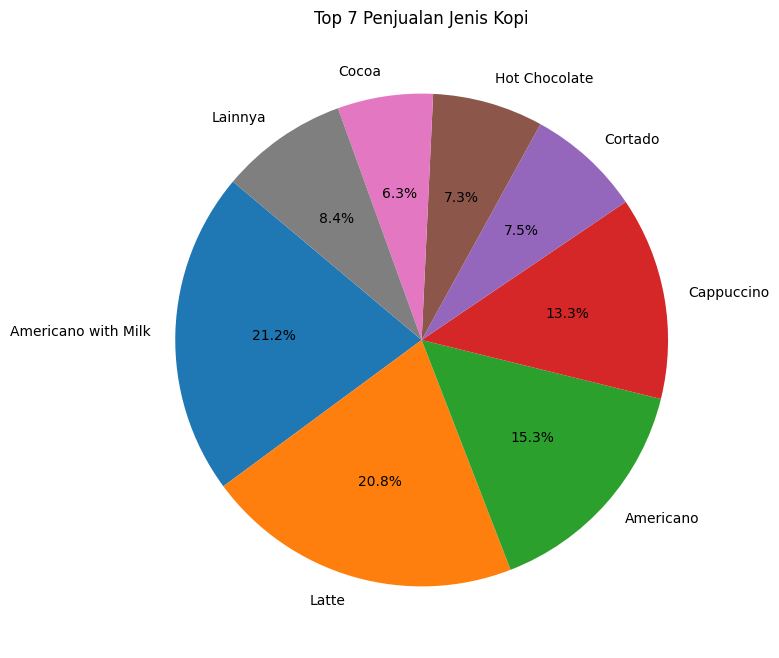

In [ ]:
top_coffee = coffee_counts.head(7)
others = pd.Series([coffee_counts.iloc[7:].sum()], index=['Lainnya'])
coffee_final_counts = pd.concat([top_coffee, others])

plt.figure(figsize=(8, 8))
coffee_final_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    title='Top 7 Penjualan Jenis Kopi'
)

plt.ylabel('')
plt.show()